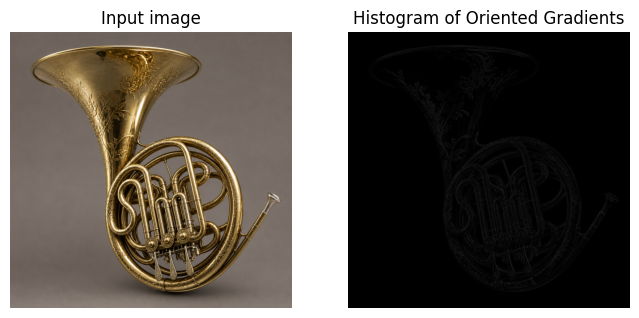

In [1]:
import matplotlib.pyplot as plt

from skimage.feature import hog
from skimage import exposure

image = plt.imread("/Users/jts/Documents/French-Horn.png")

fd, hog_image = hog(
      image,
      orientations=4,
      pixels_per_cell=(4, 4),
      cells_per_block=(1, 1),
      visualize=True,
      channel_axis=2,
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 20), sharex=True, sharey=True)

ax1.axis('off')
ax1.imshow(image, cmap=plt.cm.gray)
ax1.set_title('Input image')

# Rescale histogram for better display
hog_image_rescaled = exposure.rescale_intensity(hog_image, in_range=(0, 10))

ax2.axis('off')
ax2.imshow(hog_image_rescaled, cmap=plt.cm.gray)
ax2.set_title('Histogram of Oriented Gradients')
plt.show()

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.feature import match_template

image = plt.imread("/Users/jts/Documents/ocr-rx3.png")
coin = plt.imread("/Users/jts/Documents/ocr-rx3.png")

result = match_template(image, coin)
ij = np.unravel_index(np.argmax(result), result.shape)
x, y = ij[::-1]

fig = plt.figure(figsize=(8, 3))
ax1 = plt.subplot(1, 3, 1)
ax2 = plt.subplot(1, 3, 2)
ax3 = plt.subplot(1, 3, 3, sharex=ax2, sharey=ax2)

ax1.imshow(coin, cmap=plt.cm.gray)
ax1.set_axis_off()
ax1.set_title('template')

ax2.imshow(image, cmap=plt.cm.gray)
ax2.set_axis_off()
ax2.set_title('image')
# highlight matched region
hcoin, wcoin = coin.shape
rect = plt.Rectangle((x, y), wcoin, hcoin, edgecolor='r', facecolor='none')
ax2.add_patch(rect)

ax3.imshow(result)
ax3.set_axis_off()
ax3.set_title('`match_template`\nresult')
# highlight matched region
ax3.autoscale(False)
ax3.plot(x, y, 'o', markeredgecolor='r', markerfacecolor='none', markersize=10)

plt.show()

ValueError: too many values to unpack (expected 2, got 3)